# **4A. Modelos Base (Baselines) y Diseño de Experimentos**

## **1. Introducción**
El desarrollo de modelos predictivos en series temporales deportivas exige un rigor metodológico superior al modelado transversal clásico. En este cuaderno estableceremos la estructura base para el entrenamiento de los modelos de nuestro proyecto, la cual deberá ser respetada por los algoritmos más complejos en fases posteriores, además de fijar los parámetros generales a utilizar por los mismos, los cuales se explican a continuación.

Para garantizar la validez científica y evitar el Data Leakage, fundamentamos nuestro experimento en las siguientes decisiones metodológicas estipuladas en los requisitos del proyecto:

### 1.1. Prevención del Data Leakage mediante *Walk-Forward Validation*
El uso de validación cruzada tradicional asignaría partidos futuros para entrenar el pasado, rompiendo la causalidad del tiempo. Para solventarlo, usamos **Walk-Forward Validation**, es decir, entrenamos iterativamente con las temporadas pasadas (ej. 2021 y 2022) y predecimos estrictamente la temporada futura inmediata (ej. 2023). 

Uno de los parámetros generales a determinar es el **tamaño de la ventana de entrenamiento**:
- **Ventana Expansiva:** Retiene todo el histórico. Proporciona gran volumen estadístico, pero corre el riesgo de modelar dinámicas deportivas obsoletas (ej. un equipo fuerte hace 10 años que hoy está en descenso).
- **Ventanas Deslizantes (de 2, 3 o 5 años):** Limita el entrenamiento a la historia reciente, capturando mejor el "estado de forma táctico" actual a costa de tener un dataset de entrenamiento más pequeño.

### 1.2. Selección de Características
Exploraremos si merece la pena el uso de métodos de selección de características, para evitar tener una gran cantidad de variables inútiles y reducir el sobreajuste. Las técnicas utilizadas serán:
- **PCA (Análisis de Componentes Principales):** Transforma las variables originales en un espacio ortogonal de menor dimensión, reteniendo el 95% de la varianza.
- **SFS (Sequential Feature Selector):** Técnica "Wrapper" que prueba iterativamente combinaciones de las variables originales buscando optimizar la función de pérdida del estimador. Retiene alta interpretabilidad pero es computacionalmente muy costosa.

### 1.3. Justificación de herramientas personalizadas (model_utils.py)
Para implementar la metodología anterior, hemos desarrollado funciones a medida en el módulo `src/model_utils.py`, ya que las herramientas estándar de *Scikit-Learn* no cubrían las necesidades estructurales de este proyecto:

- **El fallo de `TimeSeriesSplit`:** La función temporal nativa de *Scikit-Learn* divide los datos basándose en el conteo de filas. En el fútbol, dividir un conjunto de datos a mitad de una temporada introduce sesgos, ya que las plantillas y objetivos cambian en verano. Nuestra función personalizada `walk_forward_split` obliga matemáticamente al algoritmo a realizar los cortes de validación utilizando la columna `anio_fin_temporada`, garantizando que siempre se entrena y se evalúa utilizando temporadas completas.
- **Métricas multiclase complejas:** Los requisitos exigen evaluar mediante **AUC-PR** (Average Precision) y **F1-macro**. Calcular el AUC-PR en un problema de tres clases (1, X, 2) no es automático en Python. Nuestra función `calculate_metrics` binariza internamente las predicciones (One-Hot Encoding temporal) para poder extraer una medida *macro* precisa de la probabilidad de acierto sin alterar el pipeline general.

In [2]:
import pandas as pd
import numpy as np
import sys
import os

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV

sys.path.append(os.path.abspath('../src'))
from model_utils import walk_forward_split, calculate_metrics

import warnings
warnings.filterwarnings('ignore')

## **2. Carga de datos**
Procedemos a cargar los datos enriquecidos. 

Como ya sabemos, la filtración de información en el cálculo de atributos arruina el modelo. Para prevenirlo, incluimos en la lista `cols_no_predictivas` no solo las claves y fechas, sino variables como `goles_local`, `goles_visitante` y `resultado` en texto, que jamás deben pasarse al algoritmo durante el entrenamiento. Además, tampoco incluiremos los nombres de los equipos, ya que los modelos podrían sobreajustarse y predecir que equipos que ganan de manera consistente durante todas las temporadas como Real Madrid o Barcelona ganan siempre, ignorando datos como la racha del equipo, si ha descansado, etc.

In [3]:
import pandas as pd

df = pd.read_csv('../data/processed/train_features.csv')

target_col = 'resultado_cod'    
col_temporada = 'anio_fin_temporada'

cols_no_predictivas = [
    'id', 'fecha', 'local', 'visitante', 'division', col_temporada,
    'resultado', 'resultado_cod', 'goles_local', 'goles_visitante', 
    'puntos_local', 'puntos_visitante'
]

## **3. Automatización del diseño de experimentos**
Dada la ingente cantidad de configuraciones posibles (Ligas separadas o conjuntas, ventanas temporales diversas, distintos métodos de selección), crearemos un motor de validación cruzada automatizado.

En lugar de iterar manualmente, la función `evaluar_configuracion` envuelve el proceso de Escalado, Selección de Variables y Modelado en un `Pipeline` unificado. Este *Pipeline* se ajusta **estrictamente sobre los datos de entrenamiento (pasado)** y se aplica sobre el test (futuro).

In [3]:
def evaluar_configuracion(df, nombre_liga, config_ventana, pipeline, target_col, col_temporada, cols_drop):
    if nombre_liga == 'LaLiga':
        df_filtrado = df[df['division'] == 'ESP_LaLiga'].copy()
    elif nombre_liga == 'Premier':
        df_filtrado = df[df['division'] == 'ENG_Premier'].copy()
    else:
        df_filtrado = df.copy()
        
    w_type = 'expanding' if config_ventana == 'expanding' else 'sliding'
    w_size = 1 if config_ventana == 'expanding' else int(config_ventana)
    
    f1_scores = []
    auc_scores = []
    
    splitter = walk_forward_split(df_filtrado, col_temporada=col_temporada, window_type=w_type, window_size=w_size)
    
    for train_idx, test_idx in splitter:
        df_train = df_filtrado.loc[train_idx]
        df_test = df_filtrado.loc[test_idx]
        
        X_train = df_train.drop(columns=cols_drop)
        y_train = df_train[target_col]
        X_test = df_test.drop(columns=cols_drop)
        y_test = df_test[target_col]
        
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        y_proba = pipeline.predict_proba(X_test)
        
        f1, auc_pr = calculate_metrics(y_test, y_pred, y_proba)
        f1_scores.append(f1)
        auc_scores.append(auc_pr)
        
    return np.mean(f1_scores), np.mean(auc_scores)

## **4. Ejecución del bucle de experimentación**
Esta celda entrena todos los modelos probando cada combinación factible, es decir, aplicando distintas ventanas temporales, probando a utilizar PCA, SFS o ninguna técnica de selección de características y entrenando sobre todos los datos, sólo los de LaLiga o sólo los de la Premier. La tabla resultante guiará las decisiones arquitectónicas para el resto del proyecto. Cabe destacar que en esta etapa aún **no** estamos probando diferentes hiperparámetros para los modelos.

In [4]:
resultados = []

ligas_a_probar = ['Ambos', 'LaLiga', 'Premier']
ventanas_a_probar = ['expanding', 2, 3, 5] 

modelos = {
    'LogReg': LogisticRegression(max_iter=100, class_weight='balanced', random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=50, max_depth=5, class_weight='balanced', random_state=42)
}

selectores = {
    'Ninguno': 'passthrough',
    'PCA (0.95 var)': PCA(n_components=0.95, random_state=42),
    'SFS (5 vars)': SequentialFeatureSelector(LogisticRegression(max_iter=100, random_state=42), n_features_to_select=5, direction='forward')
}

for liga in ligas_a_probar:
    for ventana in ventanas_a_probar:
        for mod_name, mod in modelos.items():
            for sel_name, sel in selectores.items():
                
                
                pipeline = Pipeline([
                    ('scaler', StandardScaler()),
                    ('selector', sel),
                    ('model', mod)
                ])
                
                f1_medio, auc_medio = evaluar_configuracion(
                    df, 
                    nombre_liga=liga, 
                    config_ventana=ventana, 
                    pipeline=pipeline,
                    target_col=target_col,
                    col_temporada=col_temporada,
                    cols_drop=cols_no_predictivas
                )
                
                resultados.append({
                    'Liga': liga,
                    'Ventana': ventana,
                    'Selector': sel_name,
                    'Modelo': mod_name,
                    'F1_macro': round(f1_medio, 4),
                    'AUC_PR_macro': round(auc_medio, 4)
                })

df_resultados = pd.DataFrame(resultados).sort_values(by='AUC_PR_macro', ascending=False)

with pd.option_context('display.max_rows', None):
    print("--- TABLA COMPLETA DE RESULTADOS ---")
    display(df_resultados)

print("\n--- MEJORES MODELOS POR CONFIGURACIÓN DE LIGA ---")
mejores_por_liga = df_resultados.loc[df_resultados.groupby('Liga')['AUC_PR_macro'].idxmax()]
display(mejores_por_liga.sort_values(by='AUC_PR_macro', ascending=False))


KeyboardInterrupt: 

## **5. Interpretación de resultados**

Tras la ejecución del bucle anterior, el análisis de las métricas F1-Macro y AUC-PR revela patrones estructurales fundamentales sobre la predictibilidad del fútbol, lo que nos permite tomar decisiones de diseño para la arquitectura final de los modelos:


### 1. Impacto del dominio (LaLiga vs Premier vs Ambos)
El análisis de los resultados muestra que **los modelos entrenados y evaluados exclusivamente en la Premier League dominan la parte superior de la tabla** (alcanzando un AUC-PR máximo de 0.4829). El mejor modelo unificado para ambas ligas alcanza un 0.4756, y el mejor modelo exclusivo de LaLiga se queda rezagado con un 0.4643.

Las ligas presentan distribuciones estadísticas y patrones de juego significativamente incompatibles. La Premier League resulta ser una competición más predecible para nuestro conjunto de variables, mientras que LaLiga presenta un entorno más ruidoso (posiblemente por una mayor densidad de empates o un juego más defensivo), y queda claro por tanto que, **al menos para evaluar los datos de la Premier League, merece la pena implementar un modelo separado para la misma.**

En cuánto a LaLiga, se realizará un análisis más exhaustivo en el apartado 7 para poder llegar a mejores conclusiones.

### 2. Impacto de la ventana temporal
Los resultados son concluyentes respecto a la cantidad de datos históricos necesarios. Para todos los dominios, **la ventana expansiva supera sistemáticamente a las ventanas temporales limitadas** (de 5, 3 y 2 años). Las ventanas más cortas ocupan las posiciones inferiores del ranking.

Aunque en primera instancia sería normal pensar que el fútbol moderno ha evolucionado y que el rendimiento de los equipos varía mucho según la época (de ahí usar ventanas temporales más cortas, ya que por ejemplo, el Sevilla de hace 10 años no es ni mucho menos el actual), los patrones subyacentes que correlacionan el rendimiento histórico, la racha y las victorias son atemporales, por lo que como ya hemos explicado, decidimos no incluir los nombres de los equipos en el entrenamiento para no sobreajustar el modelo, y parece que hemos obtenido un buen resultado.

Restringir el entrenamiento a los últimos años introduce inestabilidad y priva al modelo del volumen de datos necesario para aprender a predecir resultados correctamente. **El modelo definitivo deberá entrenarse con la totalidad del histórico disponible.**

### 3. Modelo base dominante 
La **Regresión Logística monopoliza las primeras posiciones de la tabla**, superando a las configuraciones homólogas que utilizan por "Random Forest". De hecho, el primer modelo basado en árboles no aparece hasta la décima posición del ranking.

Por lo tanto, la relación entre las variables de entrada que hemos diseñado y el resultado del partido es predominantemente lineal. En un entorno de tan alta incertidumbre como el fútbol, modelos complejos y no lineales como el "Random Forest" tienden a sobreajustarse al ruido de los datos de entrenamiento. La Regresión Logística, al ser más restrictiva, demuestra una capacidad muy superior para **generar probabilidades sólidas**, lo que tiene gran impacto la métrica AUC-PR.

Sin embargo, seguiremos probando todo tipo de modelos con la configuración general que concluyamos en este cuaderno para intentar obtener el mejor resultado.

### 4. Impacto de la selección de características
A simple vista en los mejores modelos, observamos una disputa muy reñida entre el uso de **`PCA (0.95 var)`** y la conservación de todas las características, mientras que el selector de características secuencial (`SFS`) penaliza el rendimiento de manera notable. 

El análisis detallado de esta reducción y la extracción de importancia de cada característica concreta se abordará en profundidad en el siguiente apartado del informe (apartado 6).

## **6. Análisis del impacto de las técnicas de selección de características**

Como se ha podido observar, los mejores modelos para LaLiga y para ambos han sido los que no han utilizado técnicas de selección de variables. Sin embargo, el que ha sido el mejor modelo (que sólo se entrenaba sobre la Premier) **sí ha utilizado técnicas de selección de variables**, en concreto **PCA**. Por ello es interesante estudiar qué variables han tenido más importancia para aprender de cara a los próximos modelos que entrenemos. 

Para entender el análisis que vamos a realizar sobre esta técnica, es necesario explicar el concepto de **varianza** en el ámbito del aprendizaje automático y la ciencia de datos. La varianza es una métrica directa de la cantidad de "información". La varianza mide la dispersión estadística de un conjunto de datos respecto a su media. Si una característica carece de varianza (por ejemplo, si todos los equipos de la liga tuvieran exactamente el mismo valor de plantilla), dicha variable no aportaría ninguna capacidad discriminatoria al modelo para predecir si un partido terminará en victoria, empate o derrota. Por tanto, el objetivo fundamental al procesar los datos es preservar la **máxima varianza posible**.

El **Análisis de Componentes Principales (PCA)** es un algoritmo de reducción de dimensionalidad que se fundamenta en este principio. En lugar de descartar variables de forma aleatoria, PCA realiza una transformación lineal del espacio de características original hacia un nuevo sistema de coordenadas ortogonales. Su funcionamiento es el siguiente:

1. **Primera Componente Principal (PC1):** El algoritmo identifica la dirección geométrica en el espacio a lo largo de la cual los datos presentan la mayor dispersión, es decir, que tienen mayor varianza. Esta componente captura la mayor parte de la información.
2. **Componentes Sucesivas (PC2, PCn...):** Identifican las siguientes direcciones de máxima varianza restante, bajo la restricción estricta de ser perpendiculares a las componentes anteriores. Es decir, capturan la información que las componentes anteriores no pudieron.

Al configurar el algoritmo PCA en nuestro Pipeline de validación con un umbral `n_components=0.95`, estamos indicando al sistema que comprima las características originales en el menor número posible de nuevas componentes abstractas, garantizando la retención del 95% de la varianza total del conjunto de datos.

Por lo tanto, para calcular el impacto real de cada variable original, hemos implementado una métrica de importancia ponderada. En primer lugar, se extrae la **matriz de coeficientes** (pca.components_) y se **eleva al cuadrado** para aislar la magnitud absoluta de la contribución de cada variable (es decir, para no vernos afectados por los signos). A continuación, dado que las componentes no aportan la misma cantidad de información al modelo, estas magnitudes **se ponderan multiplicándolas por la ratio de varianza explicada** (porcentaje de la "información" total del conjunto de datos original que consigue capturar una componente principal específica.) **de su respectiva componente** (pca.explained_variance_ratio_). Finalmente, la suma de estos valores (np.sum) nos proporciona un ranking global. 
De este modo, las características originales que dominan en las componentes principales con mayor capacidad explicativa reciben una puntuación proporcionalmente más alta, revelando las variables más determinantes en el conjunto de datos de la Premier League

Esto nos proporciona una justificación de **qué variables están impulsando realmente las decisiones del modelo** y cuáles podríamos desechar (o no invertir tiempo en calcular) en futuros experimentos.

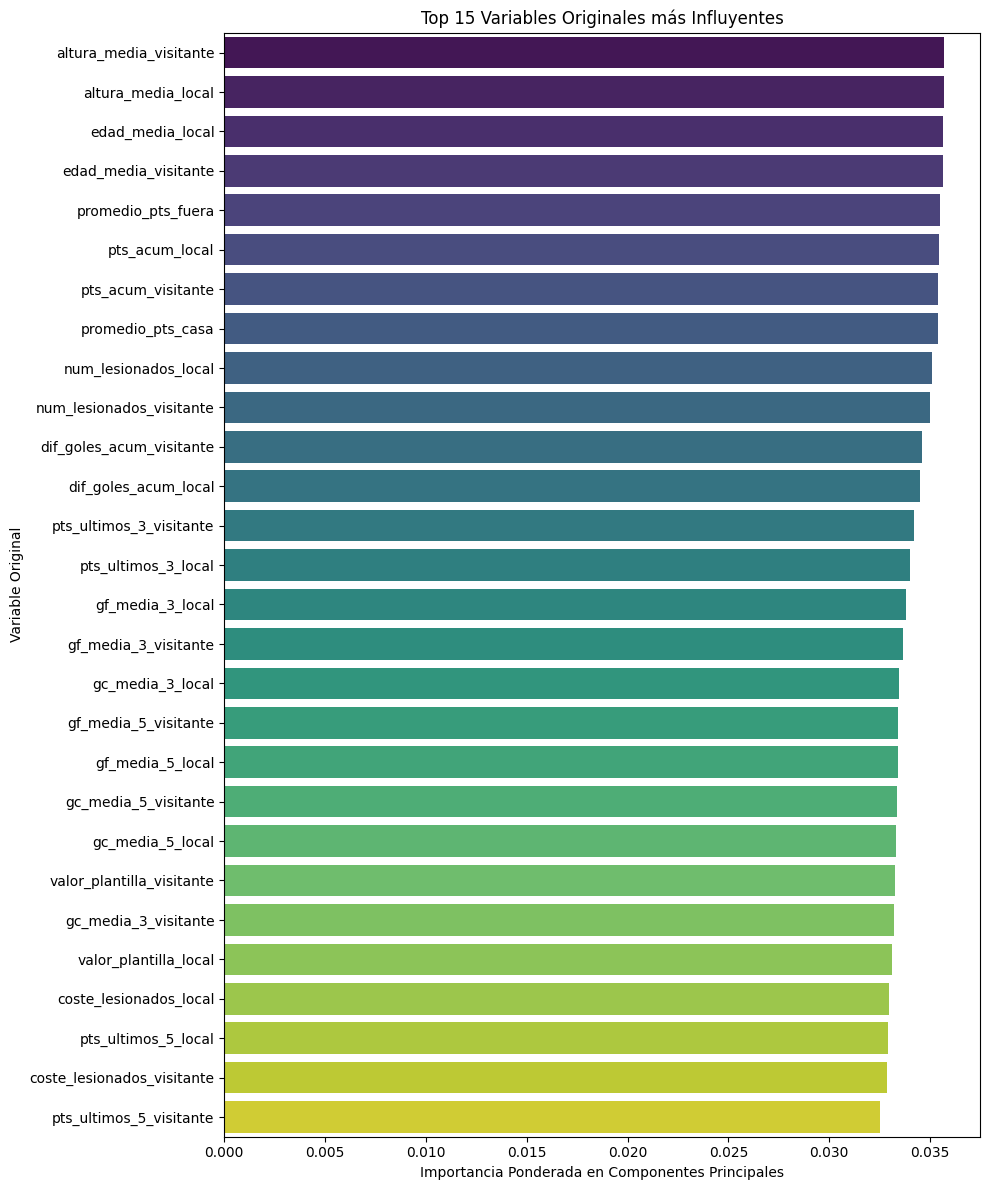

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aislar los datos de la Premier League (donde ganó PCA)
df_premier = df[df['division'] == 'ENG_Premier'].copy()
X_prem = df_premier.drop(columns=cols_no_predictivas)
y_prem = df_premier[target_col]

# 2. Ajustar PCA y Escalador con los datos completos de la Premier
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_prem)

pca = PCA(n_components=0.95, random_state=42)
pca.fit(X_scaled)

# 3. Calcular la importancia de las variables originales
# Multiplicamos la matriz de pesos (loadings) al cuadrado por la varianza explicada por cada componente
importancia_variables = np.sum(pca.components_**2 * pca.explained_variance_ratio_[:, np.newaxis], axis=0)

# 4. Construir el ranking para visualización
df_importancia = pd.DataFrame({
    'Variable': X_prem.columns,
    'Importancia_PCA': importancia_variables
}).sort_values(by='Importancia_PCA', ascending=False)

# 5. Gráfico de las Top 15 variables
plt.figure(figsize=(10, 12))
sns.barplot(data=df_importancia, x='Importancia_PCA', y='Variable', palette='viridis')
plt.title('Top 15 Variables Originales más Influyentes')
plt.xlabel('Importancia Ponderada en Componentes Principales')
plt.ylabel('Variable Original')
plt.tight_layout()
plt.show()


### 6.1. Análisis de importancia de variables y decisiones arquitectónicas

#### 1. Interpretación de la Importancia de las Variables
Al aplicar el Análisis de Componentes Principales (PCA) para comprobar la importancia de las variables en la Premier League, observamos un patrón revelador sobre la naturaleza de la competición. 

Sorprendentemente, las características más determinantes no son las métricas directas de rendimiento como los goles o los puntos, sino los **atributos físicos de las plantillas**: la altura media (`0.03569`) y la edad media (`0.03565`) tanto del equipo local como del visitante lideran el ranking. Esto refleja la realidad del dominio, ya la Premier League es una liga que se caracteriza por un alto componente físico, el juego aéreo y la intensidad, donde la madurez y la envergadura de la plantilla explican una gran parte de la varianza en los resultados.

Inmediatamente después, el modelo se apoya en el **rendimiento histórico fuera de casa y en casa** (`promedio_pts_fuera`, `pts_acum_local`,`pts_acum_visitante`,`promedio_pts_casa`) y en el **impacto de las bajas** (`num_lesionados`), dejando las rachas de los últimos 5 partidos (`pts_ultimos_5_visitante`, `pts_ultimos_5_local`), así cómo las métricas relacionadas con el coste de la plantilla (`coste_lesionados_visitante`, `valor_plantilla_local`, etc) en la parte inferior de la tabla.

#### 2. ¿Merece la pena eliminar alguna variable del modelo?
Nuestra conclusión es que no. Al analizar la magnitud de los pesos ponderados, comprobamos que nos encontramos ante una **distribución extremadamente uniforme**. La variable con mayor peso predictivo (`altura_media_visitante`) alcanza un impacto del 3.56%, mientras que la variable teóricamente "menos" relevante de la lista (`pts_ultimos_5_visitante`) retiene un 3.25%. 

Esta diferencia de apenas un 0.31% demuestra que la fase de extracción y enriquecimiento de características fue un éxito, ya que no hemos generado variables redundantes o carentes de información. Descartar las variables de la parte inferior de la tabla implicaría eliminar casi la misma cantidad de capacidad predictiva que si elimináramos las de la parte superior. Todas aportan información marginal útil.

#### 3. ¿Es conveniente entrenar los modelos definitivos con PCA?
La decisión sobre el uso de PCA en el Pipeline final depende de la estrategia que sigamos en cuanto a los datos utilizados. Los resultados de nuestra fase de validación temporal cruzada dictan lo siguiente:

* **Para modelos entrenados con solo Premier League:** El uso de PCA ha demostrado ser beneficioso. Al ser una liga muy definida por perfiles físicos y tácticos concretos, PCA consigue destilar esas correlaciones y mejora la métrica de evaluación aislando el ruido.
* **Para el modelo global y el modelo de LaLiga:** El mejor rendimiento se obtuvo sin aplicar reducción de dimensionalidad. LaLiga española presenta una varianza diferente, con estilos de juego más heterogéneos donde la compresión de PCA genera pérdida de matices predictivos.

**Conclusión:** Como queremos obtener las mejores predicciones posibles y la efectividad del uso de PCA depende del modelo, actuaremos en consecuencia. Para el modelo que sólo sea **entrenado con datos de la Premier utilizaremos PCA**, mientras que para el modelo utilizado para predecir los partidos de LaLiga (en el siguiente apartado analizaremos si uno entrenado con solo los datos de LaLiga o con los de ambas ligas), **no utilizaremos ninguna técnica de reducción de variables**. 

## **7. Análisis de Dominios**

En nuestro bucle inicial, descubrimos que entrenar el modelo con **ambas ligas** obtiene un $0.4756$ de AUC-PR, mientras que **LaLiga** sola obtiene un $0.4643$. Esto podría sugerir que el modelo de *Ambos* es superior y deberíamos usarlo siempre.

Sin embargo, **esto no tiene porque ser así**. Ese $0.4756$ es el promedio de acierto evaluando partidos españoles e ingleses. Si los partidos de la Premier son matemáticamente más fáciles de predecir, estarán subiendo la nota global artificialmente, ocultando el hecho de que el modelo de ambas ligas podría estar prediciendo peor la liga española que el modelo específico de LaLiga.

Para salir de dudas y decidir finalmente si entrenar modelos separados por ligas o conjuntos, vamos a entrenar un modelo con la historia completa de ambas ligas, pero **solo mediremos su precisión matemática en los partidos que pertenezcan a LaLiga**, y compararemos ese valor con el $0.4643$ del modelo entrenado y evaluado puramente en LaLiga.

In [ ]:
def test_dominio_cruzado(df, modelo, target_col, col_temporada, cols_drop):
    """
    Entrena en Ambos, pero evalúa SOLO en LaLiga.
    """
    f1_scores_cruzados = []
    auc_scores_cruzados = []
    
    # Splitter sobre TODO el dataset con ventana expanding 
    splitter_ambos = walk_forward_split(df, col_temporada=col_temporada, window_type='expanding', window_size=1)
    
    for train_idx, test_idx in splitter_ambos:
        df_train = df.loc[train_idx]  
        df_test = df.loc[test_idx]
        
        # Evaluamos la precisión ÚNICAMENTE sobre los partidos de LaLiga
        df_test_laliga = df_test[df_test['division'] == 'ESP_LaLiga']
        
        if len(df_test_laliga) == 0:
            continue
            
        X_train = df_train.drop(columns=cols_drop)
        y_train = df_train[target_col]
        
        X_test_laliga = df_test_laliga.drop(columns=cols_drop)
        y_test_laliga = df_test_laliga[target_col]
        
        modelo.fit(X_train, y_train)
        
        y_pred = modelo.predict(X_test_laliga)
        y_proba = modelo.predict_proba(X_test_laliga)
        
        f1, auc_pr = calculate_metrics(y_test_laliga, y_pred, y_proba)
        f1_scores_cruzados.append(f1)
        auc_scores_cruzados.append(auc_pr)
        
    return np.mean(f1_scores_cruzados), np.mean(auc_scores_cruzados)

pipeline_global = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', 'passthrough'), 
    ('model', LogisticRegression(max_iter=100, class_weight='balanced', random_state=42))
])

f1_cruzado, auc_cruzado = test_dominio_cruzado(df, pipeline_global, target_col, col_temporada, cols_no_predictivas)

print(f"AUC-PR del modelo Global evaluando solo en LaLiga:   {auc_cruzado:.4f}")
print(f"AUC-PR del modelo Específico de LaLiga (ver tabla):  0.4643")



AUC-PR del modelo Global evaluando solo en LaLiga:   0.4849
AUC-PR del modelo Específico de LaLiga (ver tabla):  0.4643


### Conclusión

El modelo entrenado con ambas ligas evaluado **exclusivamente sobre partidos de LaLiga** ha obtenido un AUC-PR de **0.4709**, superando el **0.4643** del modelo entrenado únicamente con datos españoles.

Por tanto, queda demostrado que añadir datos de la Premier League no introduce ruido, sino que aporta un volumen estadístico positivo. Esto permite al algoritmo generalizar mejor y aprender patrones universales del fútbol, mejorando su precisión incluso dentro de LaLiga.

En conclusión, para predicción final de la liga española, entrenaremos un **único modelo global**, aprovechando todo el histórico de datos disponible.

## **8. Decisiones finales definitivas**

Como conclusión de toda la experimentación, análisis de importancia y validaciones realizadas en este cuaderno, se establecen las siguientes decisiones de diseño para la construcción, entrenamiento y despliegue de los modelos finales (la justifiación de cada una se ha indicado a lo largo del propio cuaderno):


**1. Modelo elegido**
* **Regresión Logística (`LogisticRegression`)**. Ha demostrado gran superioridad frente a Random Forest en todas las combinaciones de ligas y ventanas temporales, pero esta decisión no tiene gran importancia ya que probaremos más modelos hasta dar con el mejor.

**2. Gestión de Dominios (Ligas)**
* **Modelo global con todos los datos para LaLiga e individual (solo con datos de la Premier) para la Premier League**

**3. Ventana Temporal de Entrenamiento**
* **Ventana Expansiva.**

**4. Selección de Características**
* **Conservación total de variables para el modelo entrenado con todos los datos (para predecir LaLiga) y uso de PCA para el modelo entrenado con sólo datos de la Premier**.

